In [76]:
import torch
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
def plot_metric_across_alphas(run_data, metric_name, type, alphas, seeds):
    """
    Plots a specific metric for all alphas with error bars and removed top/right borders.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = plt.cm.get_cmap('tab10', len(alphas))
   
    for i, alpha in enumerate(alphas):
        train_aux_values = []
        for seed in seeds:
            data_matrix = run_data[metric_name][alpha]
            data_dict = data_matrix[seed].item()
            train_aux_values.append(data_dict[type])
                
        # Calculate statistics
        min_len = min(len(arr) for arr in train_aux_values)
        truncated_matrix = np.stack([arr[:min_len] for arr in train_aux_values])

        mean_vector = np.mean(truncated_matrix, axis=0)
        std_vector = np.std(truncated_matrix, axis=0)
        epochs = np.arange(len(mean_vector))
        color = colors(i)
        
        # Plot with error bars instead of fill_between
        # 'errorevery=5' prevents the plot from becoming too cluttered
        ax.errorbar(
            epochs, 
            mean_vector, 
            yerr=std_vector, 
            label=f'α={alpha}', 
            color=color, 
            linewidth=2,
            capsize=3,
            errorevery=1, 
            alpha=0.8
        )

    # --- Styling ---
    # Remove top and right spines (borders)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_title(f'Mean {metric_name.capitalize()} {type.capitalize()} across Seeds', fontsize=14)
    ax.set_xlabel('Epochs')
    ax.set_ylabel(metric_name.capitalize())
    ax.legend(title="Alpha Values", frameon=False) # Removed frame to match clean style
    
    plt.tight_layout()
    plt.show()
# --- Example Usage ---
# plot_metric_across_alphas(run_data, 'accs', alphas=[0.1, 0.5, 1.0])
# plot_metric_across_alphas(run_data, 'losses', alphas=[0.1, 0.5, 1.0])
    


In [77]:
    
import torch
import numpy as np
from pathlib import Path


seeds = list(range(30))
alphas=[0.01,0.1,0.5,1.0,2,5,10]
alphas=[1.0]
base_path = Path("/nfs/nhome/live/cdomine/old_sam/multi-task/data/cifar/pretrain_fr_block_1vit/")
run_data = {
    'losses': {a: [] for a in alphas},
    'accs': {a: [] for a in alphas},
    'models': {a: [] for a in alphas},
    'l2_regs': {a: [] for a in alphas}
}

for alpha in alphas:
    for seed in seeds:
        folder_name = (
            f"random_seed={seed}"
           # f"--alpha_policy=fr_block_123--alpha={alpha}"
        )
        
        dir_path = base_path / folder_name
        if dir_path.exists():
            # Load and append data to the lists
            if (dir_path / "losses.npy").exists():
                run_data['losses'][alpha].append(np.load(dir_path / "losses.npy",allow_pickle=True))
                print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Losses")
            if (dir_path / "accs.npy").exists():
                run_data['accs'][alpha].append(np.load(dir_path / "accs.npy",allow_pickle=True))
                print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Accs")
        else:
            print(f"Missing directory: {folder_name}")

# Convert lists to numpy arrays for easier math later: run_data['accs'][0.1] will be (10, epochs)
for metric in ['losses', 'accs','l2_regs']:
    for alpha in alphas:
        if run_data[metric][alpha]:
            run_data[metric][alpha] = np.array(run_data[metric][alpha])





✅ Loaded Seed 0, Alpha 1.0, Losses
✅ Loaded Seed 0, Alpha 1.0, Accs
✅ Loaded Seed 1, Alpha 1.0, Losses
✅ Loaded Seed 1, Alpha 1.0, Accs
✅ Loaded Seed 2, Alpha 1.0, Losses
✅ Loaded Seed 2, Alpha 1.0, Accs
✅ Loaded Seed 3, Alpha 1.0, Losses
✅ Loaded Seed 3, Alpha 1.0, Accs
✅ Loaded Seed 4, Alpha 1.0, Losses
✅ Loaded Seed 4, Alpha 1.0, Accs
✅ Loaded Seed 5, Alpha 1.0, Losses
✅ Loaded Seed 5, Alpha 1.0, Accs
✅ Loaded Seed 6, Alpha 1.0, Losses
✅ Loaded Seed 6, Alpha 1.0, Accs
✅ Loaded Seed 7, Alpha 1.0, Losses
✅ Loaded Seed 7, Alpha 1.0, Accs
✅ Loaded Seed 8, Alpha 1.0, Losses
✅ Loaded Seed 8, Alpha 1.0, Accs
✅ Loaded Seed 9, Alpha 1.0, Losses
✅ Loaded Seed 9, Alpha 1.0, Accs
✅ Loaded Seed 10, Alpha 1.0, Losses
✅ Loaded Seed 10, Alpha 1.0, Accs
✅ Loaded Seed 11, Alpha 1.0, Losses
✅ Loaded Seed 11, Alpha 1.0, Accs
✅ Loaded Seed 12, Alpha 1.0, Losses
✅ Loaded Seed 12, Alpha 1.0, Accs
✅ Loaded Seed 13, Alpha 1.0, Losses
✅ Loaded Seed 13, Alpha 1.0, Accs
✅ Loaded Seed 14, Alpha 1.0, Losses
✅ Lo

/tmp/ipykernel_353725/2253447913.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(alphas))


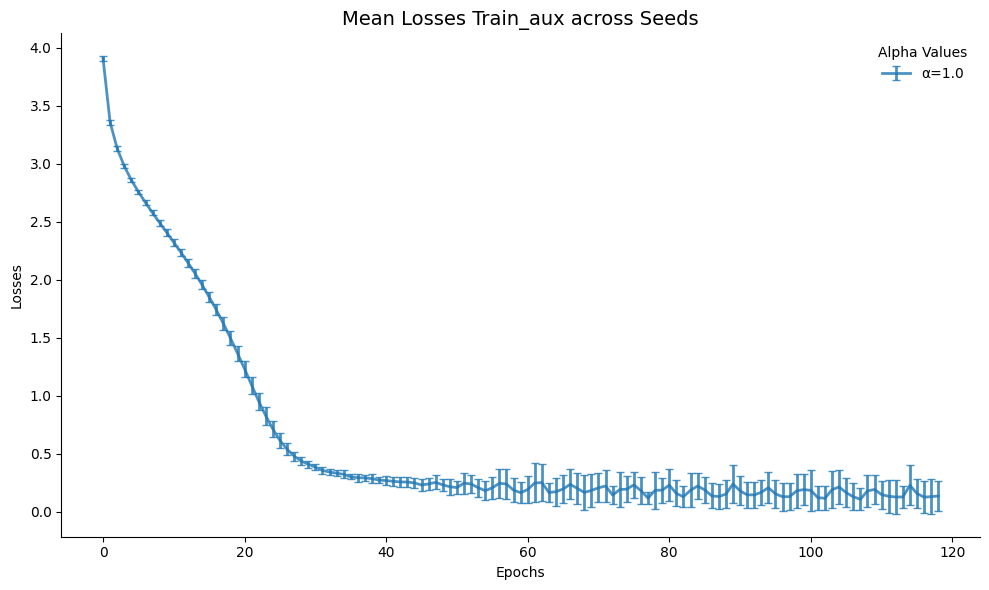

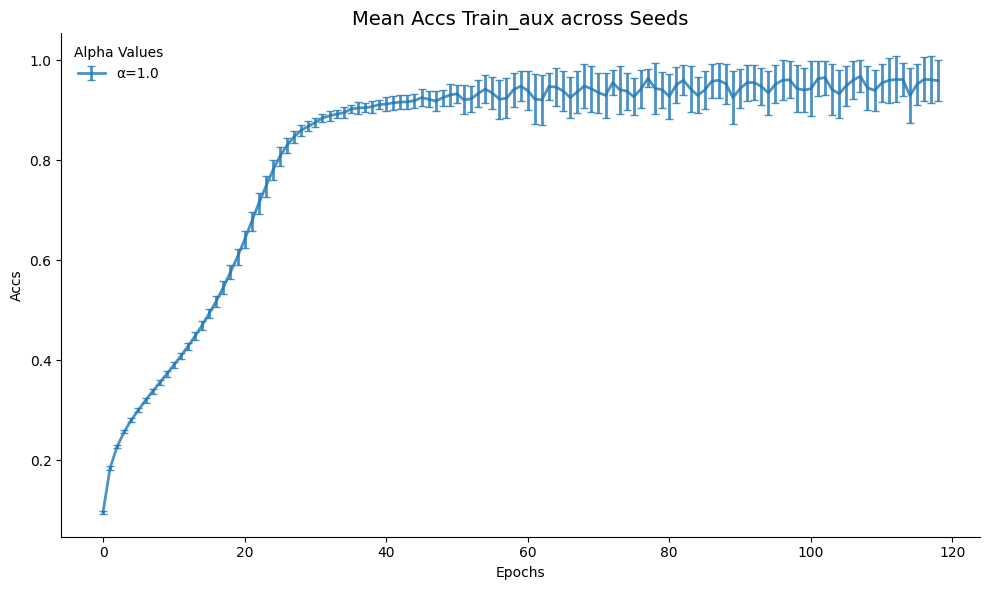

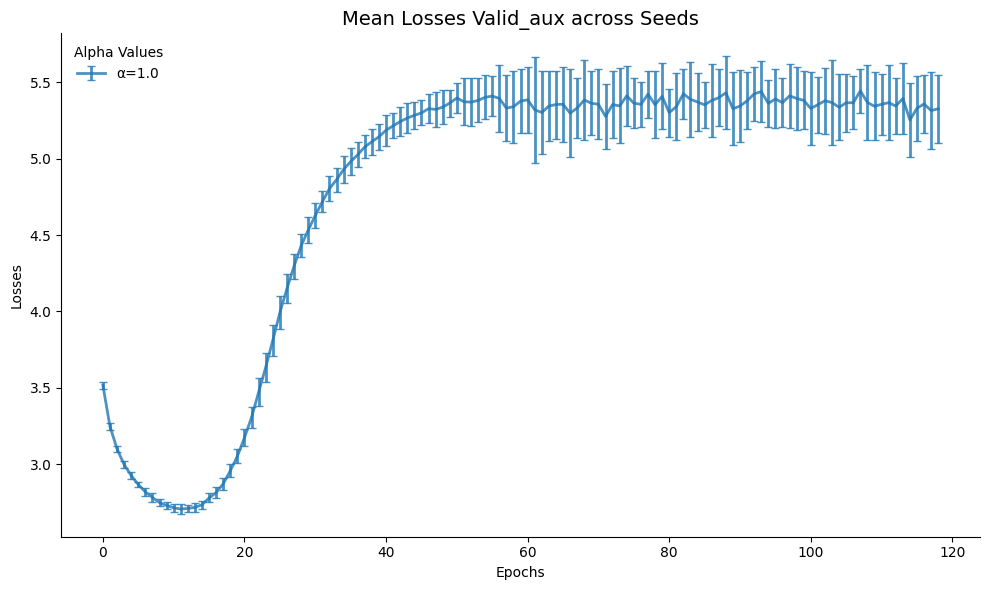

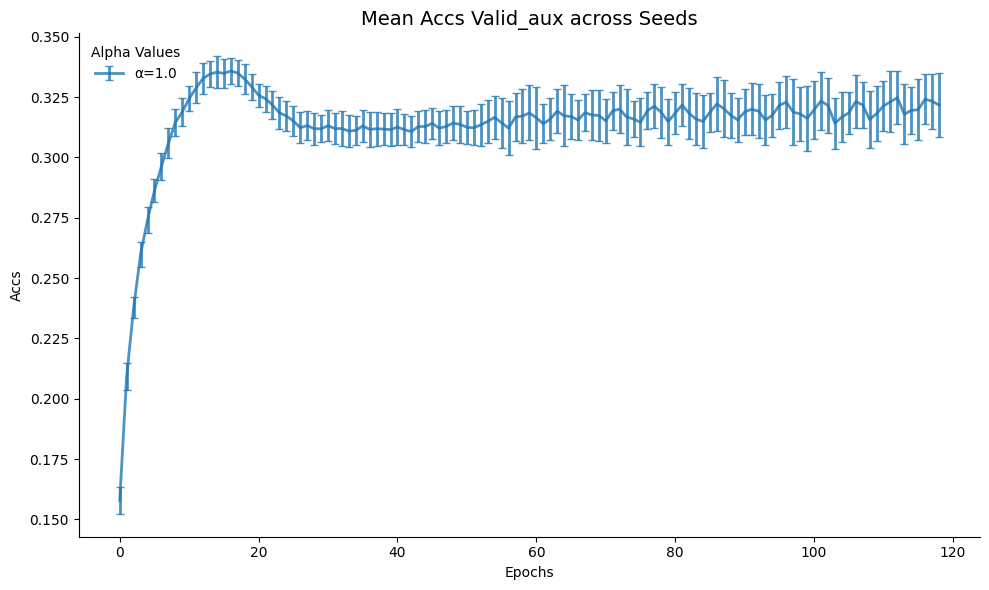

In [78]:
seeds = list(range(30))
plot_metric_across_alphas(run_data, 'losses','train_aux' ,   alphas=[1.0],seeds=seeds) #plot_metric_across_alphas(run_data, 'losses', alphas=[0.1, 0.5, 1.0])
plot_metric_across_alphas(run_data, 'accs', 'train_aux', alphas=[1.0],seeds=seeds)
plot_metric_across_alphas(run_data, 'losses','valid_aux' , alphas=[1.0],seeds=seeds) #plot_metric_across_alphas(run_data, 'losses', alphas=[0.1, 0.5, 1.0])
plot_metric_across_alphas(run_data, 'accs', 'valid_aux' , alphas=[1.0],seeds=seeds) #

/tmp/ipykernel_353725/2253447913.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(alphas))


KeyError: 0.01

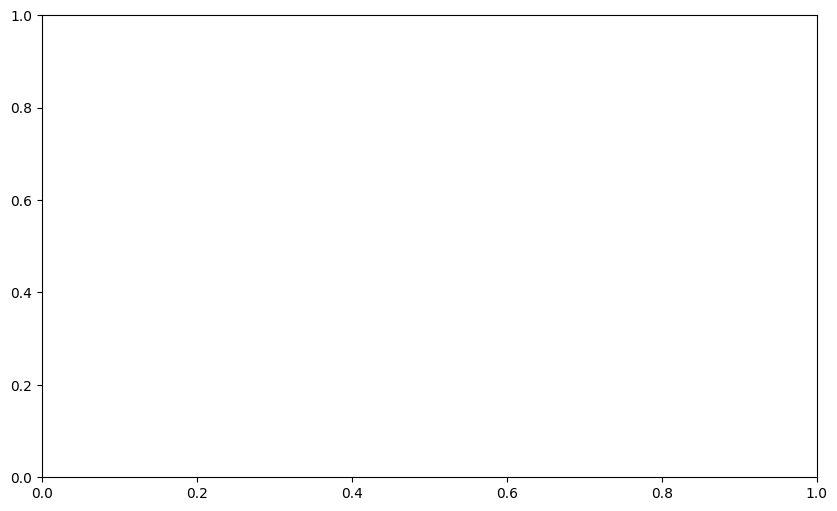

In [79]:
seeds = list(range(30))
plot_metric_across_alphas(run_data, 'losses','train_aux' ,   alphas=[0.01,0.1,0.5,1.0,2,5,10],seeds=seeds) #plot_metric_across_alphas(run_data, 'losses', alphas=[0.1, 0.5, 1.0])
plot_metric_across_alphas(run_data, 'accs', 'train_aux', alphas=[0.01,0.1,0.5,1.0,2,5,10],seeds=seeds)
plot_metric_across_alphas(run_data, 'losses','valid_aux' , alphas=[0.01,0.1,0.5,1.0,2,5,10],seeds=seeds) #plot_metric_across_alphas(run_data, 'losses', alphas=[0.1, 0.5, 1.0])
plot_metric_across_alphas(run_data, 'accs', 'valid_aux' , alphas=[0.01,0.1,0.5,1.0,2,5,10],seeds=seeds) #


In [ ]:
import torch
import numpy as np
from pathlib import Path
seeds = list(range(50))
alphas = [0.125, 0.25, 0.5, 1., 2.]
n_samples=[10, 20, 50, 100, 200, 500, 1000]
base_path = Path("/nfs/gatsbystor/cdomine/cifar_testing/cifar/extentions")

run_data = {
    'losses': {a:{s: [] for s in n_samples} for a in alphas},
    'accs': {a: {s: [] for s in n_samples} for a in alphas},
    'models': {a: {s: [] for s in n_samples} for a in alphas},
    'l2_regs': {a: {s: [] for s in n_samples} for a in alphas}
}
for alpha in alphas:
    for seed in seeds:
        for n_sample in n_samples :
            folder_name = (
                f"random_seed={seed}--mode=finetuning--n_samples={ n_sample}--"
                f"finetune_scaling={alpha}"
            )
            
            dir_path = base_path / folder_name
            if dir_path.exists():
                #  print(f" {seed}, finetune {alpha}, Sample {n_sample}, Accs"),
                # Load and append data to the lists
                if (dir_path / "losses.npy").exists():
                    run_data['losses'][alpha][n_sample].append(np.load(dir_path / "losses.npy",allow_pickle=True))
                  #    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Losses")
                if (dir_path / "l2_regs.npy").exists():
                    run_data['l2_regs'][alpha][n_sample].append(np.load(dir_path / "l2_regs.npy",allow_pickle=True))
                    #  print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, l2_regs")
                if (dir_path / "accs.npy").exists():
                    run_data['accs'][alpha][n_sample].append(np.load(dir_path / "accs.npy",allow_pickle=True))
                    #  print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
            else:
                print(f"Missing directory: {folder_name}")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _err_from_vals(vals, error_type="se"):
    vals = np.asarray(vals, dtype=float)
    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    err = std if error_type == "std" else std / np.sqrt(len(vals))
    return mean, err

def plot_merged_run_and_csv(
    run_data,
    csv_path,
    metric_name,          # key in run_data
    type_val,             # e.g. "train" or "valid" inside dict
    alphas,
    seeds,
    samples,
    csv_metric="valid",   # column in CSV to plot
    csv_mode=None,        # "finetuning" / "multitask" / None
    group_col="scaling",  # grouping column in CSV (like alpha)
    log_x=True,
    use_one_minus_acc=True,
    error_type="se",      # "std" or "se"
):
    assert error_type in {"std", "se"}

    fig, ax = plt.subplots(figsize=(10, 6))

    # separate color palettes to make both sources visible
    run_cmap = plt.colormaps["tab10"] if hasattr(plt, "colormaps") else plt.cm.get_cmap("tab10")
    csv_cmap = plt.colormaps["tab20"] if hasattr(plt, "colormaps") else plt.cm.get_cmap("tab20")

    # --------- RUN_DATA PLOT (alpha curves) ----------
    metric_lower = str(metric_name).lower()
    do_one_minus_run = use_one_minus_acc and ("acc" in metric_lower or "accuracy" in metric_lower)

    for i, alpha in enumerate(alphas):
        means, errs = [], []

        for sample in samples:
            vals = []
            for seed in seeds:
                try:
                    data_matrix = run_data[metric_name][alpha][sample]
                    v = data_matrix[seed]
                    data_dict = v.item() if hasattr(v, "item") else v

                    y = np.max(data_dict[type_val])
                    if do_one_minus_run:
                        y = 1.0 - y
                    vals.append(y)
                except (KeyError, IndexError, TypeError, ValueError):
                    continue

            if len(vals) == 0:
                means.append(np.nan)
                errs.append(np.nan)
            else:
                m, e = _err_from_vals(vals, error_type=error_type)
                means.append(m)
                errs.append(e)

        # If everything is NaN, nothing will appear
        if np.all(np.isnan(means)):
            print(f"[WARN] run_data: α={alpha} produced all-NaN (likely key mismatch / missing data). Skipping.")
            continue

        ax.errorbar(
            samples, means, yerr=errs,
            label=f"run scale={alpha}",
            color=run_cmap(i % 10),
            linestyle="-",
            marker="o",
            linewidth=2.5,
            capsize=4,
            alpha=0.95,
            zorder=3,  # on top
        )

    # --------- CSV PLOT (scaling curves) ----------
    df = pd.read_csv(csv_path)

    # numeric coercion (blank cells -> NaN)
    for c in [csv_metric, group_col, "n_samples"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    if csv_mode is not None and "mode" in df.columns:
        df = df[df["mode"] == csv_mode]

    df = df.dropna(subset=[csv_metric, "n_samples"])

    mlow = str(csv_metric).lower()
    do_one_minus_csv = use_one_minus_acc and (
        "acc" in mlow or "accuracy" in mlow or csv_metric in {"train", "valid"}
    )

    groups = sorted(df[group_col].dropna().unique().tolist())
    x_vals = sorted(df["n_samples"].dropna().unique().tolist())

    for j, g in enumerate(groups):
        means, errs = [], []
        dfg = df[df[group_col] == g]

        for x in x_vals:
            vals = dfg[dfg["n_samples"] == x][csv_metric].dropna().to_numpy()
            if len(vals) == 0:
                means.append(np.nan)
                errs.append(np.nan)
            else:
                if do_one_minus_csv:
                    vals = 1.0 - vals
                m, e = _err_from_vals(vals, error_type=error_type)
                means.append(m)
                errs.append(e)

        if np.all(np.isnan(means)):
            print(f"[WARN] csv: {group_col}={g} produced all-NaN. Skipping.")
            continue

        ax.errorbar(
            x_vals, means, yerr=errs,
            label=f"csv {group_col}={g}",
            color=csv_cmap(j % 20),
            linestyle="--",
            marker="s",
            linewidth=2,
            capsize=4,
            alpha=0.75,
            zorder=2,
        )

    # --------- Styling ----------
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if log_x:
        ax.set_xscale("log")

    errlab = "Std. Error" if error_type == "se" else "Std. Dev."
    ax.set_title(f"Merged plot (error bars = {errlab})", fontsize=14, pad=12)
    ax.set_xlabel("Sample Size", fontsize=11)
    ax.set_ylabel("Metric", fontsize=11)

    ax.legend(frameon=False, loc="best")
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
import torch
import numpy as np
from pathlib import Path
seeds = list(range(30))
alphas = [0.3,0.5,1.0,2,5,10]
 #/nfs/gatsbystor/cdomine/cifar_testing/cifar/main_3/
n_samples=[10, 20, 50, 100, 200, 500, 1000]
#random_seed=0--mode=finetuning--n_samples=10--alpha=1.0--alpha_policy=first_vs_rest--model=resnet
base_path = Path("/nfs/gatsbystor/cdomine/cifar_testing/cifar/extentions_all_pretrain_fr_block_1vit_base/")
 #base_path = Path("/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/main_3/")
run_data = {
    'losses': {a:{s: [] for s in n_samples} for a in alphas},
    'accs': {a: {s: [] for s in n_samples} for a in alphas},
    'models': {a: {s: [] for s in n_samples} for a in alphas},
    'l2_regs': {a: {s: [] for s in n_samples} for a in alphas}
}
for alpha in alphas:
    for seed in seeds:
        for n_sample in n_samples :
            folder_name = (
                f"random_seed={seed}--mode=finetuning--n_samples={n_sample}--finetune_scaling={alpha}"
            )

            dir_path = base_path / folder_name
            if dir_path.exists():
              #    print(f" {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
                # Load and append data to the lists
                if (dir_path / "losses.npy").exists():
                    run_data['losses'][alpha][n_sample].append(np.load(dir_path / "losses.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Losses")
                if (dir_path / "l2_regs.npy").exists():
                    run_data['l2_regs'][alpha][n_sample].append(np.load(dir_path / "l2_regs.npy",allow_pickle=True))
                   #   print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, l2_regs")
                if (dir_path / "accs.npy").exists():
                    run_data['accs'][alpha][n_sample].append(np.load(dir_path / "accs.npy",allow_pickle=True))
                   #   print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
            else:
                print(f"Missing directory: {folder_name}")

✅ Loaded Seed 0, Alpha 0.3, Sample 10, Losses
✅ Loaded Seed 0, Alpha 0.3, Sample 20, Losses
✅ Loaded Seed 0, Alpha 0.3, Sample 50, Losses
✅ Loaded Seed 0, Alpha 0.3, Sample 100, Losses
✅ Loaded Seed 0, Alpha 0.3, Sample 200, Losses
✅ Loaded Seed 0, Alpha 0.3, Sample 500, Losses
✅ Loaded Seed 0, Alpha 0.3, Sample 1000, Losses
✅ Loaded Seed 1, Alpha 0.3, Sample 10, Losses
✅ Loaded Seed 1, Alpha 0.3, Sample 20, Losses
✅ Loaded Seed 1, Alpha 0.3, Sample 50, Losses
✅ Loaded Seed 1, Alpha 0.3, Sample 100, Losses
✅ Loaded Seed 1, Alpha 0.3, Sample 200, Losses
✅ Loaded Seed 1, Alpha 0.3, Sample 500, Losses
✅ Loaded Seed 1, Alpha 0.3, Sample 1000, Losses
✅ Loaded Seed 2, Alpha 0.3, Sample 10, Losses
✅ Loaded Seed 2, Alpha 0.3, Sample 20, Losses
✅ Loaded Seed 2, Alpha 0.3, Sample 50, Losses
✅ Loaded Seed 2, Alpha 0.3, Sample 100, Losses
✅ Loaded Seed 2, Alpha 0.3, Sample 200, Losses
✅ Loaded Seed 2, Alpha 0.3, Sample 500, Losses
✅ Loaded Seed 2, Alpha 0.3, Sample 1000, Losses
✅ Loaded Seed 3, Al

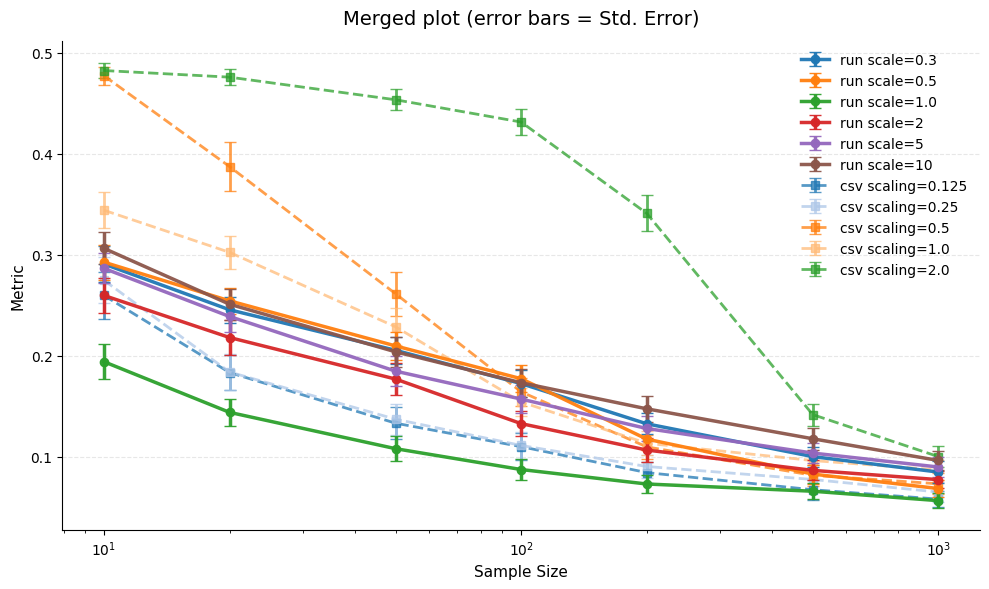

In [ ]:
plot_merged_run_and_csv(
    run_data=run_data,
    #csv_path="/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/resnet_acc_max.csv",
    csv_path="/nfs/gatsbystor/cdomine/cifar_testing/cifar/resnet_acc_max_main_samscale_sam.csv",
    metric_name="accs",
    type_val="valid",
    alphas = [0.3,0.5,1.0,2,5,10],
    seeds=list(range(50)),
    samples=[10, 20, 50, 100, 200, 500, 1000],
    csv_metric="valid",
    csv_mode="finetuning",
    error_type="se")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _err_from_vals(vals, error_type="se"):
    vals = np.asarray(vals, dtype=float)
    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    err = std if error_type == "std" else std / np.sqrt(len(vals))
    return mean, err

def plot_merged_run_and_csv(
    run_data,
    metric_name,          # key in run_data
    type_val,             # e.g. "train" or "valid" inside dict
    alphas,
    seeds,
    samples,
    log_x=True,
    use_one_minus_acc=True,
    error_type="se",      # "std" or "se"
):
    assert error_type in {"std", "se"}

    fig, ax = plt.subplots(figsize=(10, 6))

    # separate color palettes to make both sources visible
    run_cmap = plt.colormaps["tab10"] if hasattr(plt, "colormaps") else plt.cm.get_cmap("tab10")
    csv_cmap = plt.colormaps["tab20"] if hasattr(plt, "colormaps") else plt.cm.get_cmap("tab20")

    # --------- RUN_DATA PLOT (alpha curves) ----------
    metric_lower = str(metric_name).lower()
    do_one_minus_run = use_one_minus_acc and ("acc" in metric_lower or "accuracy" in metric_lower)

    for i, alpha in enumerate(alphas):
        means, errs = [], []

        for sample in samples:
            vals = []
            for seed in seeds:
                try:
                    data_matrix = run_data[metric_name][alpha][sample]
                    v = data_matrix[seed]
                    data_dict = v.item() if hasattr(v, "item") else v

                    y = np.max(data_dict[type_val])
                    if do_one_minus_run:
                        y = 1.0 - y
                    vals.append(y)
                except (KeyError, IndexError, TypeError, ValueError):
                    continue

            if len(vals) == 0:
                means.append(np.nan)
                errs.append(np.nan)
            else:
                m, e = _err_from_vals(vals, error_type=error_type)
                means.append(m)
                errs.append(e)

        # If everything is NaN, nothing will appear
        if np.all(np.isnan(means)):
            print(f"[WARN] run_data: α={alpha} produced all-NaN (likely key mismatch / missing data). Skipping.")
            continue

        ax.errorbar(
            samples, means, yerr=errs,
            label=f"run scale={alpha}",
            color=run_cmap(i % 10),
            linestyle="-",
            marker="o",
            linewidth=2.5,
            capsize=4,
            alpha=0.95,
            zorder=3,  # on top
        )


    # --------- Styling ----------
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if log_x:
        ax.set_xscale("log")

    errlab = "Std. Error" if error_type == "se" else "Std. Dev."
    ax.set_title(f"Merged plot (error bars = {errlab})", fontsize=14, pad=12)
    ax.set_xlabel("Sample Size", fontsize=11)
    ax.set_ylabel("Metric", fontsize=11)

    ax.legend(frameon=False, loc="best")
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

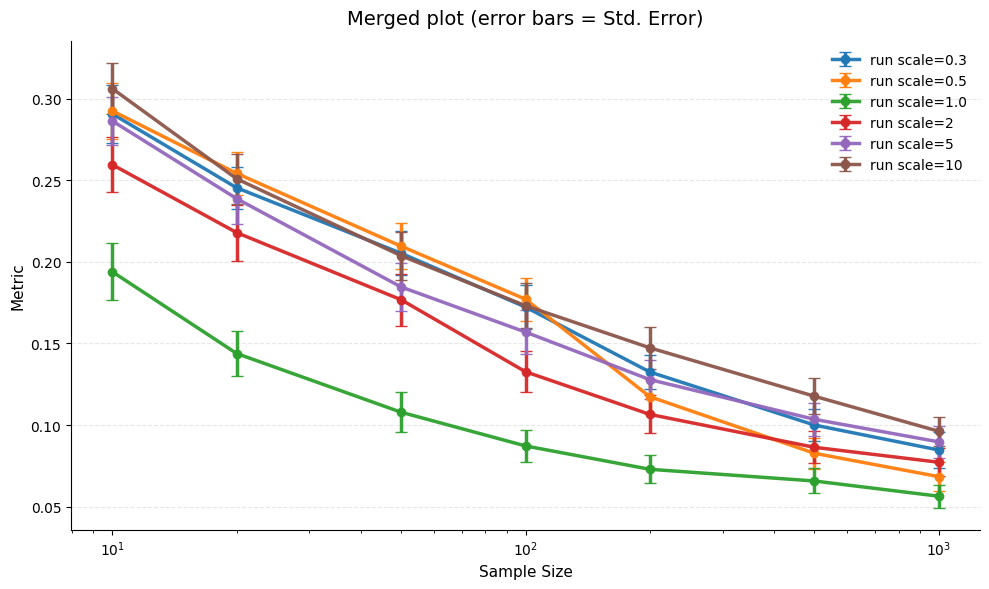

In [ ]:
plot_merged_run_and_csv(
    run_data=run_data,
    #csv_path="/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/resnet_acc_max.csv",
    metric_name="accs",
    type_val="valid",
    alphas = [0.3,0.5,1.0,2,5,10],
    seeds=list(range(50)),
    samples=[10, 20, 50, 100, 200, 500, 1000],
    error_type="se")


In [ ]:
# This is concatenated with the maximal validation error, we can also run it with the error at the end.
import os
import pandas as pd
import numpy as np
import plotnine as gg
import torch
import numpy as np
from pathlib import Path

base_path = Path("/nfs/gatsbystor/cdomine/cifar_testing/cifar/main_samscale_sam/")

df = []
for folder in os.listdir('/nfs/gatsbystor/cdomine/cifar_testing/cifar/main_samscale_sam/'):
    if 'accs.npy' in os.listdir(f'/nfs/gatsbystor/cdomine/cifar_testing/cifar/main_samscale_sam/{folder}') and\
    (folder.split('--')[1].split('=')[1] != 'finetuning' or len(folder.split('--'))==5):
        new_df = pd.DataFrame({
            k: [v.max()] for k,v in np.load(f'/nfs/gatsbystor/cdomine/cifar_testing/cifar/main_samscale_sam/{folder}/accs.npy', allow_pickle=True)[()].items()\
            if len(v)!=0
            }
        )
        new_df['rs'] = folder.split('--')[0].split('=')[1]
        new_df['mode'] = folder.split('--')[1].split('=')[1]
        new_df['n_samples'] = int(folder.split('--')[2].split('=')[1])
        if folder.split('--')[1].split('=')[1] == 'finetuning':
            new_df['scaling'] = float(folder.split('--')[3].split('=')[1])
        df.append(new_df)
df = pd.concat(df)

df.to_csv('/nfs/gatsbystor/cdomine/cifar_testing/cifar/main_samscale_sam/resnet_acc_max.csv')

(gg.ggplot(df[(df['scaling']==1)|np.isnan(df['scaling'])], gg.aes('n_samples', '1-valid', color='mode')) +
 gg.stat_summary(geom='line') +
 gg.stat_summary(geom='linerange') +
 gg.scale_x_log10() +
 gg.scale_y_log10())
(gg.ggplot(df[df['mode']=='finetuning'], gg.aes('n_samples', '1-valid', color='scaling', group='scaling')) +
 gg.stat_summary(geom='line') +
 gg.stat_summary(geom='linerange') +
 gg.scale_x_log10())

ENSD

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_values_by_alpha(
    run_data,
    split_name=None,
    *,
    n_sample=100,
    alphas=(0.1, 0.5, 1.0),
    seeds=None,
    variables=("ENSD", "PR Pre", "PR Post"),
    split_col=("split", "dataset", "name"),
):
    """
    One subplot per alpha.
    Each subplot shows metrics vs layer using error bars and clean styling.
    """

    n_alpha = len(alphas)
    fig, axes = plt.subplots(
        1, n_alpha,
        figsize=(5 * n_alpha, 4),
        sharex=True,
        sharey=True
    )

    # Ensure axes is always a list/array even with 1 subplot
    if n_alpha == 1:
        axes = [axes]

    for ax, alpha in zip(axes, alphas):
        df_list = run_data["df"].get(alpha, {}).get(n_sample, [])
        if not df_list:
            ax.set_title(f"α={alpha} (no data)")
            # Despine even for empty plots to keep look consistent
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            continue

        rows = []
        for df in df_list:
            d = df.copy()

            if seeds is not None and "seed" in d.columns:
                d = d[d["seed"].isin(seeds)]

            if split_name is not None:
                found_col = next((c for c in split_col if c in d.columns), None)
                if found_col is not None:
                    d = d[d[found_col] == split_name]

            d = d[d["variable"].isin(variables)]
            if d.empty:
                continue
            rows.append(d)

        if not rows:
            ax.set_title(f"α={alpha} (empty)")
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            continue

        df_all = pd.concat(rows, ignore_index=True)

        # ---- mean + std over seeds/runs ----
        stats = (
            df_all
            .groupby(["variable", "layer"])["value"]
            .agg(mean="mean", std="std")
            .reset_index()
            .sort_values(["variable", "layer"])
        )

        # ---- plot ----
        for var in variables:
            sub = stats[stats["variable"] == var]

            # Use errorbar instead of plot + fill_between
            ax.errorbar(
                sub["layer"],
                sub["mean"],
                yerr=sub["std"],
                marker="o",
                label=var,
                linewidth=2,
                capsize=3,
                alpha=0.8
            )

        # Clean Style Adjustments
        ax.set_title(f"α = {alpha}", fontsize=12, pad=10)
        ax.set_xlabel("Layer")
        
        # Remove top and right borders
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Use a very light grid or remove it
        ax.grid(True, axis='y', linestyle='--', alpha=0.3)

    axes[0].set_ylabel("Value")
    axes[-1].legend(loc="upper right", frameon=False)

    fig.suptitle(
        f"Metrics vs Layer (mean ± std over seeds) | n_samples={n_sample}",
        fontsize=14,
        y=1.02
    )

    plt.tight_layout()
    plt.show()
    plot_values_by_alpha(
    run_data,
    split_name="valid_aux",   # Filters for validation auxiliary data
    n_sample=1000,
    alphas=[0.1, 0.5, 1.0],
    seeds=seeds
)


In [80]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path

# --- Configuration ---
seeds = list(range(20))
n_samples= [10, 50, 100, 200, 500, 1000]
alphas = [0.01,0.1,0.5,1.0,2,5,10]
base_path = Path("/nfs/nhome/live/cdomine/old_sam/multi-task/data/cifar/ensd_123_last/")

# Nested dictionary for structured access
run_data = {
    "df": {a: {s: [] for s in n_samples} for a in alphas},
}
all_long = []  # Stores long-format rows for every run
all_wide = []  # Stores wide-format per run

# --- Data Loading Loop ---
for alpha in alphas:
    for seed in seeds:
        for n_sample in n_samples:
            # Construct folder name based on experimental parameters
            folder_name = (
                f"random_seed={seed}--n_samples={n_sample}--alpha_load={alpha}"
            )
            dir_path = base_path / folder_name
            csv_path = dir_path / "df.csv"

            if not csv_path.exists():
                print(f'not downloaded {csv_path}')
                continue

            # --- Read CSV (long format: value, variable, layer) ---
            df = pd.read_csv(csv_path)

            # Cleanup: drop stray index column if present
            if "Unnamed: 0" in df.columns:
                df = df.drop(columns=["Unnamed: 0"])

            # Ensure expected columns exist
            expected = {"value", "variable", "layer"}
            missing = expected - set(df.columns)
            if missing:
                raise ValueError(f"{csv_path} is missing columns: {missing}")

            # Enforce data types
            df["value"] = df["value"].astype(float)
            df["layer"] = df["layer"].astype(int)

            # Add metadata for filtering/grouping
            df["alpha"] = float(alpha)
            df["seed"] = int(seed)
            df["n_samples"] = int(n_sample)

            # Save in nested structure and global list
            run_data["df"][alpha][n_sample].append(df)
            all_long.append(df)
            # --- Optional: build wide-format for this run ---
            # Transforms: Layer | Variable_A_Value | Variable_B_Value
            df_wide = (
                df.pivot(index="layer", columns="variable", values="value")
                  .reset_index()
            )
            df_wide["alpha"] = float(alpha)
            df_wide["seed"] = int(seed)
            df_wide["n_samples"] = int(n_sample)
            all_wide.append(df_wide)

# --- Final Aggregation ---
if all_long:
    df_all_long = pd.concat(all_long, ignore_index=True)
else:
    df_all_long = pd.DataFrame()

if all_wide:
    df_all_wide = pd.concat(all_wide, ignore_index=True)
else:
    df_all_wide = pd.DataFrame()
print("All long-format rows:", df_all_long.shape)
print("All wide-format rows:", df_all_wide.shape)


All long-format rows: (23520, 6)
All wide-format rows: (5880, 8)


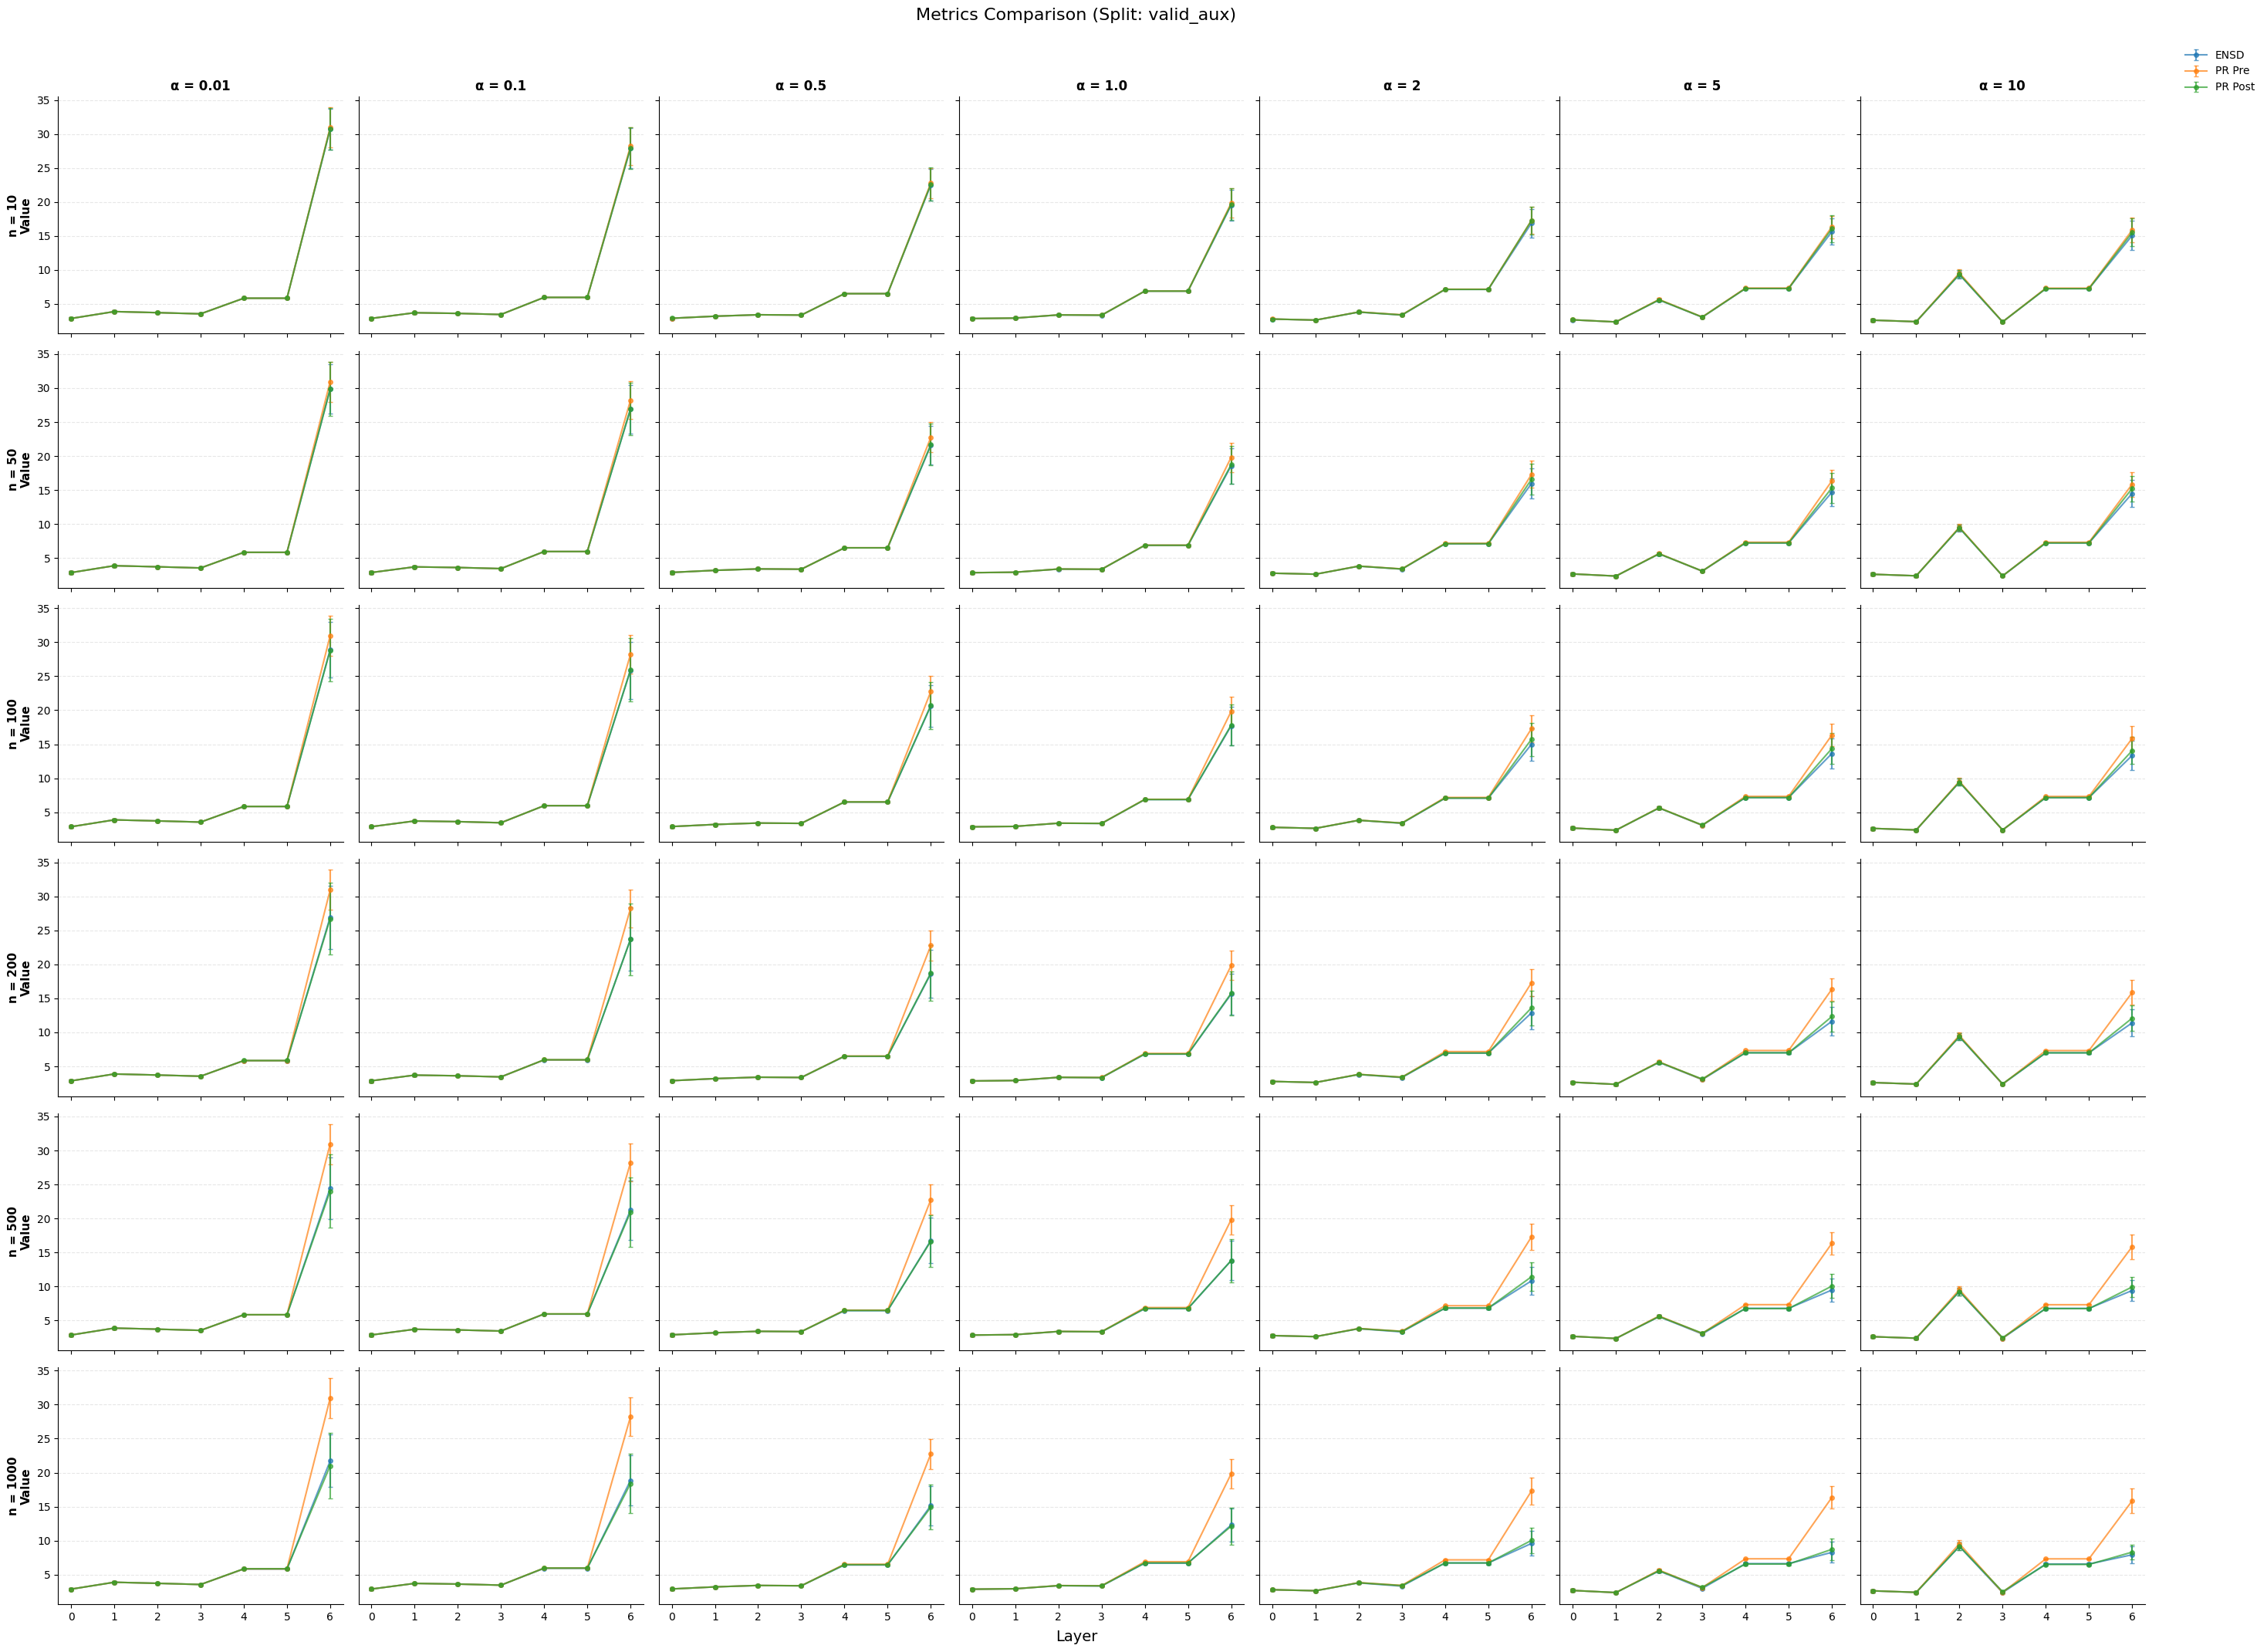

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_values_by_alpha_grid(
    run_data,
    split_name=None,
    *,
    n_samples=[100],
    alphas=(0.1, 0.5, 1.0),
    seeds=None,
    variables=("ENSD", "PR Pre", "PR Post"),
    split_col=("split", "dataset", "name"),
):
    """
    Creates a single large figure grid.
    Rows = n_samples
    Cols = alphas
    """
    num_samples = len(n_samples)
    num_alphas = len(alphas)

    # Create the grid
    fig, axes = plt.subplots(
        num_samples, num_alphas, 
        figsize=(4 * num_alphas, 3.5 * num_samples),
        sharex=True, 
        sharey=True,
        squeeze=False # Ensures axes is always a 2D array [row, col]
    )

    for row_idx, n_sample in enumerate(n_samples):
        for col_idx, alpha in enumerate(alphas):
            ax = axes[row_idx, col_idx]
            
            # Data retrieval
            df_list = run_data["df"].get(alpha, {}).get(n_sample, [])
            
            if not df_list:
                ax.set_title(f"n={n_sample}, α={alpha} (No Data)", fontsize=10)
                continue

            rows = []
            for df in df_list:
                d = df.copy()
                if seeds is not None and "seed" in d.columns:
                    d = d[d["seed"].isin(seeds)]
                if split_name is not None:
                    found_col = next((c for c in split_col if c in d.columns), None)
                    if found_col is not None:
                        d = d[d[found_col] == split_name]
                
                # Filter specifically for your 3 variables
                d = d[d["variable"].isin(variables)]
                if not d.empty:
                    rows.append(d)

            if not rows:
                continue

            df_all = pd.concat(rows, ignore_index=True)
            stats = (
                df_all.groupby(["variable", "layer"])["value"]
                .agg(mean="mean", std="std")
                .reset_index()
            )

            # Plotting
            for var in variables:
                sub = stats[stats["variable"] == var]
                ax.errorbar(
                    sub["layer"], sub["mean"], yerr=sub["std"].fillna(0),
                    marker="o", markersize=4, label=var, linewidth=1.5, capsize=2, alpha=0.7
                )

            # Labels and Styling
            if row_idx == 0:
                ax.set_title(f"α = {alpha}", fontsize=12, fontweight='bold')
            if col_idx == 0:
                ax.set_ylabel(f"n = {n_sample}\nValue", fontsize=11, fontweight='bold')
            
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, axis='y', linestyle='--', alpha=0.3)

    # Global labels
    fig.supxlabel("Layer", fontsize=14)
    fig.suptitle(f"Metrics Comparison (Split: {split_name})", fontsize=16, y=1.02)
    # Single legend for the whole figure
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.05, 1), frameon=False)
    plt.tight_layout()
    plt.show()

# Execution
plot_values_by_alpha_grid(
    run_data,
    split_name="valid_aux",
    n_samples=[10, 50, 100, 200, 500, 1000],
    alphas=[0.01, 0.1, 0.5, 1.0, 2, 5, 10],
    seeds=seeds,
    variables=["ENSD", "PR Pre", "PR Post"]
)

TypeError: plot_values_by_alpha() got an unexpected keyword argument 'n_samples'

Data successfully loaded into run_data.


All long-format rows: (23520, 6)
All wide-format rows: (5880, 8)


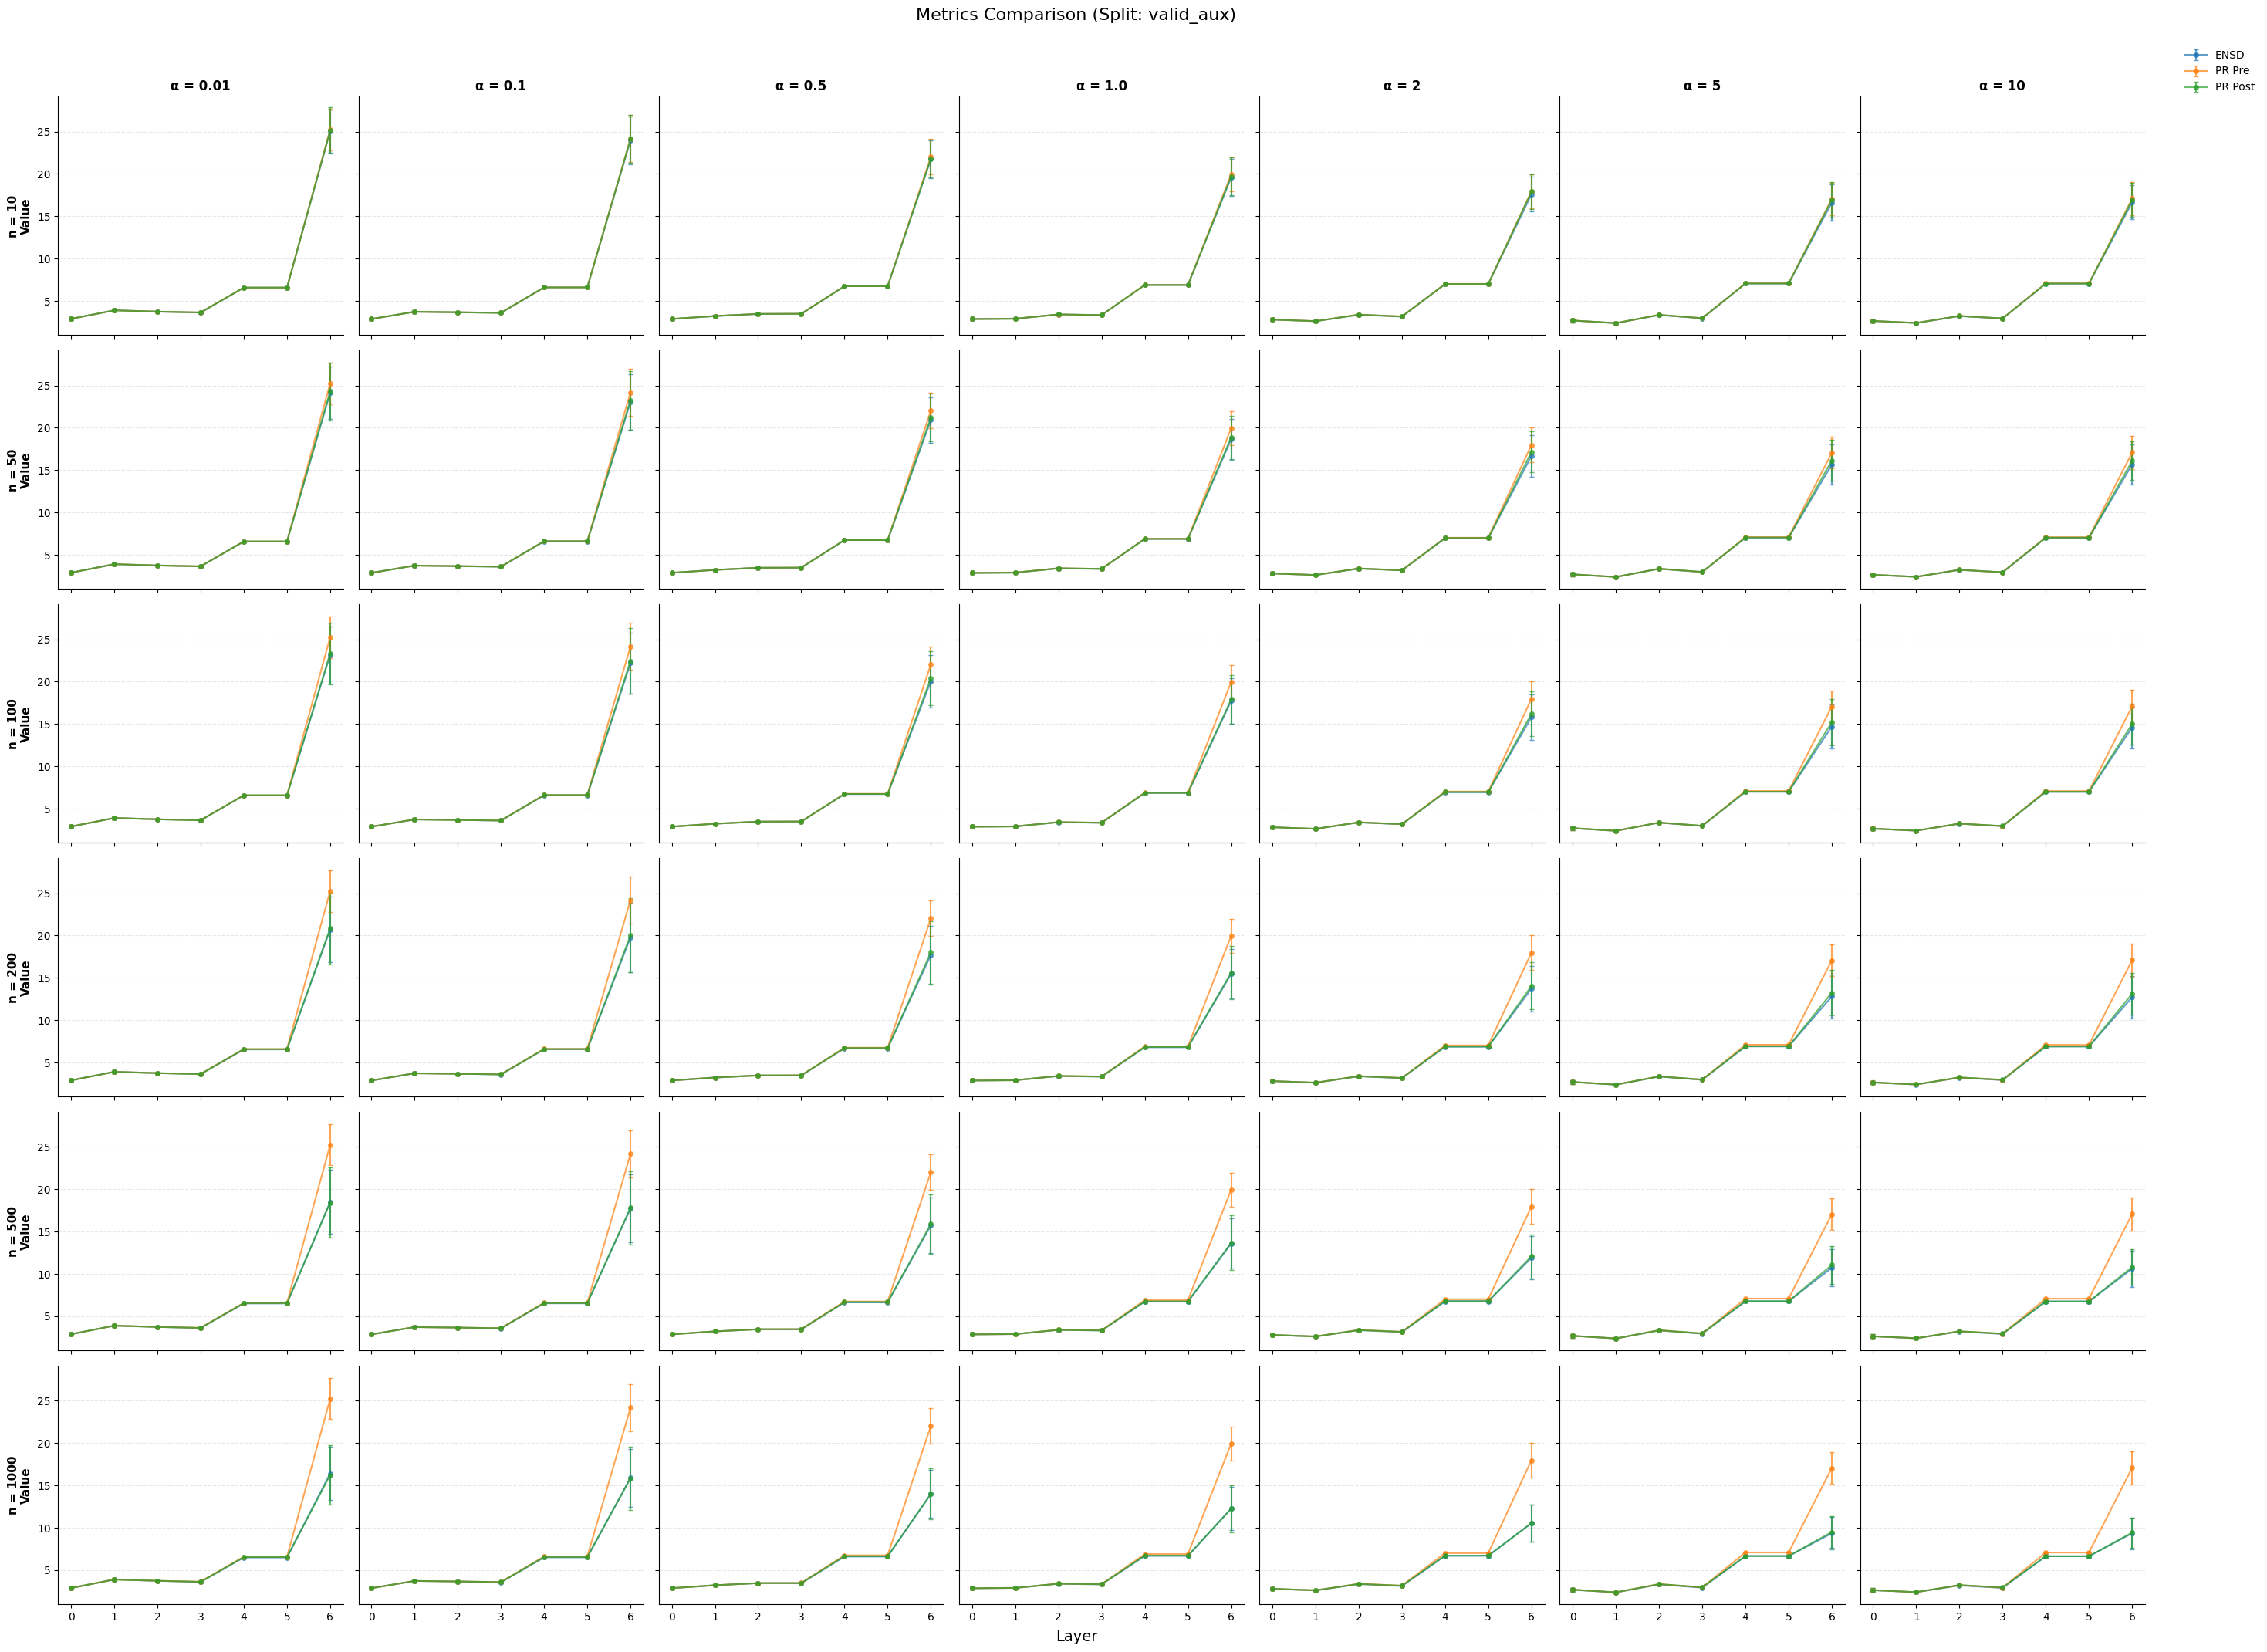

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_values_by_alpha_grid(
    run_data,
    split_name=None,
    *,
    n_samples=[100],
    alphas=(0.1, 0.5, 1.0),
    seeds=None,
    variables=("ENSD", "PR Pre", "PR Post"),
    split_col=("split", "dataset", "name"),
):
    """
    Creates a single large figure grid.
    Rows = n_samples
    Cols = alphas
    """
    num_samples = len(n_samples)
    num_alphas = len(alphas)

    # Create the grid
    fig, axes = plt.subplots(
        num_samples, num_alphas, 
        figsize=(4 * num_alphas, 3.5 * num_samples),
        sharex=True, 
        sharey=True,
        squeeze=False # Ensures axes is always a 2D array [row, col]
    )

    for row_idx, n_sample in enumerate(n_samples):
        for col_idx, alpha in enumerate(alphas):
            ax = axes[row_idx, col_idx]
            
            # Data retrieval
            df_list = run_data["df"].get(alpha, {}).get(n_sample, [])
            
            if not df_list:
                ax.set_title(f"n={n_sample}, α={alpha} (No Data)", fontsize=10)
                continue

            rows = []
            for df in df_list:
                d = df.copy()
                if seeds is not None and "seed" in d.columns:
                    d = d[d["seed"].isin(seeds)]
                if split_name is not None:
                    found_col = next((c for c in split_col if c in d.columns), None)
                    if found_col is not None:
                        d = d[d[found_col] == split_name]
                
                # Filter specifically for your 3 variables
                d = d[d["variable"].isin(variables)]
                if not d.empty:
                    rows.append(d)

            if not rows:
                continue

            df_all = pd.concat(rows, ignore_index=True)
            stats = (
                df_all.groupby(["variable", "layer"])["value"]
                .agg(mean="mean", std="std")
                .reset_index()
            )

            # Plotting
            for var in variables:
                sub = stats[stats["variable"] == var]
                ax.errorbar(
                    sub["layer"], sub["mean"], yerr=sub["std"].fillna(0),
                    marker="o", markersize=4, label=var, linewidth=1.5, capsize=2, alpha=0.7
                )

            # Labels and Styling
            if row_idx == 0:
                ax.set_title(f"α = {alpha}", fontsize=12, fontweight='bold')
            if col_idx == 0:
                ax.set_ylabel(f"n = {n_sample}\nValue", fontsize=11, fontweight='bold')
            
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, axis='y', linestyle='--', alpha=0.3)

    # Global labels
    fig.supxlabel("Layer", fontsize=14)
    fig.suptitle(f"Metrics Comparison (Split: {split_name})", fontsize=16, y=1.02)
    
    # Single legend for the whole figure
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.05, 1), frameon=False)

    plt.tight_layout()
    plt.show()

# Execution
plot_values_by_alpha_grid(
    run_data,
    split_name="valid_aux",
    n_samples=[10, 50, 100, 200, 500, 1000],
    alphas=[0.01, 0.1, 0.5, 1.0, 2, 5, 10],
    seeds=seeds,
    variables=["ENSD", "PR Pre", "PR Post"]
)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


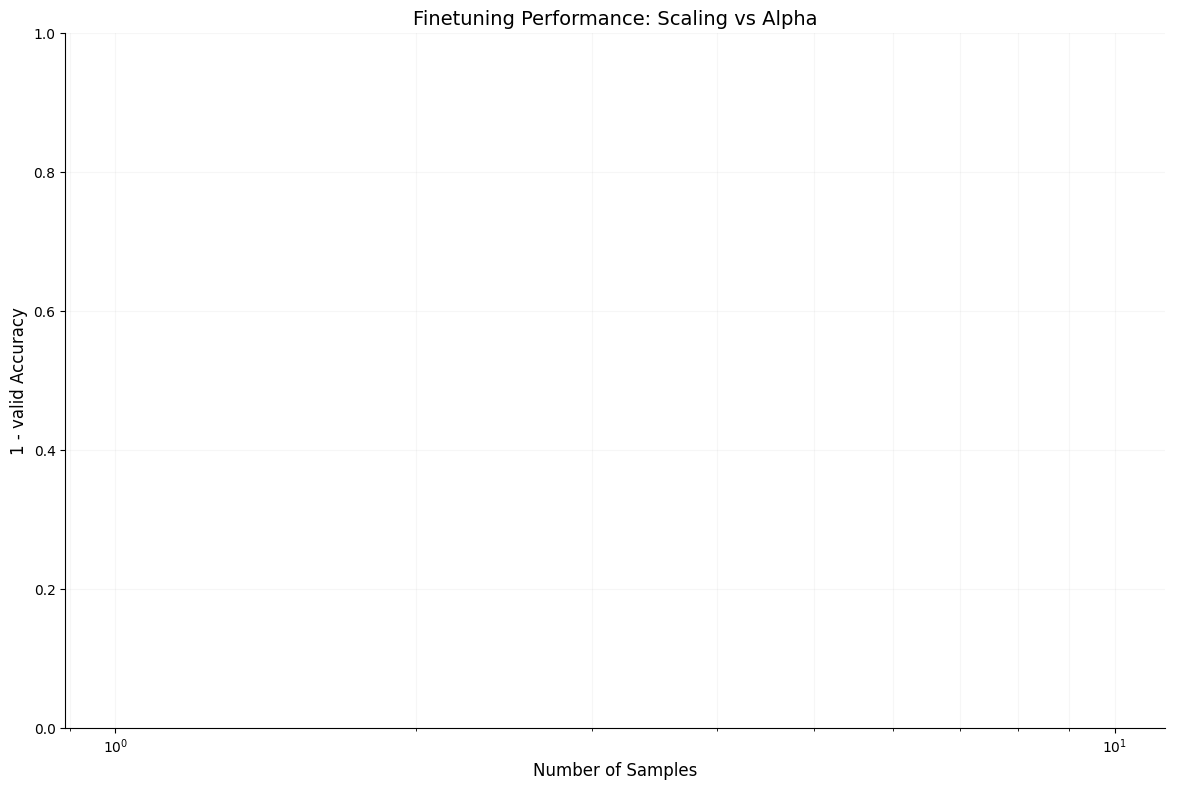

In [ ]:
import torch
import numpy as np
from pathlib import Path

# --- Configuration ---
seeds = list(range(30))
alphas = [0.3, 0.5, 1.0, 2, 5, 10]
n_samples = [10, 20, 50, 100, 200, 500, 1000]
scaling_values = [0.3, 0.5, 1.0, 2, 5, 10] # Values for finetune_scaling_last

base_path = Path("/nfs/gatsbystor/cdomine/cifar_testing/cifar/extentions_all_pretrain_fr_block_1vit_fc")

# --- Initialize Data Structure ---
# Structure: [metric][alpha][n_sample][scaling_value] -> list of seeds
metrics = ['losses', 'accs', 'l2_regs']
run_data = {
    m: {a: {n: {sc: [] for sc in scaling_values} for n in n_samples} for a in alphas} 
    for m in metrics
}

# --- Data Loading Loop ---
for alpha in alphas:
    for n_sample in n_samples:
        for sc_last in scaling_values:
            for seed in seeds:
                folder_name = (
                    f"random_seed={seed}--mode=finetuning--alpha_load={alpha}--"
                    f"n_samples={n_sample}--finetune_scaling_last={sc_last}"
                )
                
                dir_path = base_path / folder_name
                
                if dir_path.exists():
                    # Load specific files if they exist
                    for filename, key in [("losses.npy", "losses"), ("accs.npy", "accs"), ("l2_regs.npy", "l2_regs")]:
                        file_path = dir_path / filename
                        if file_path.exists():
                            data = np.load(file_path, allow_pickle=True)
                            run_data[key][alpha][n_sample][sc_last].append(data)
                else:
                    # Optional: uncomment to debug missing folders
                    # print(f"Missing: {folder_name}")
                    pass

print("Data successfully loaded into run_data.")

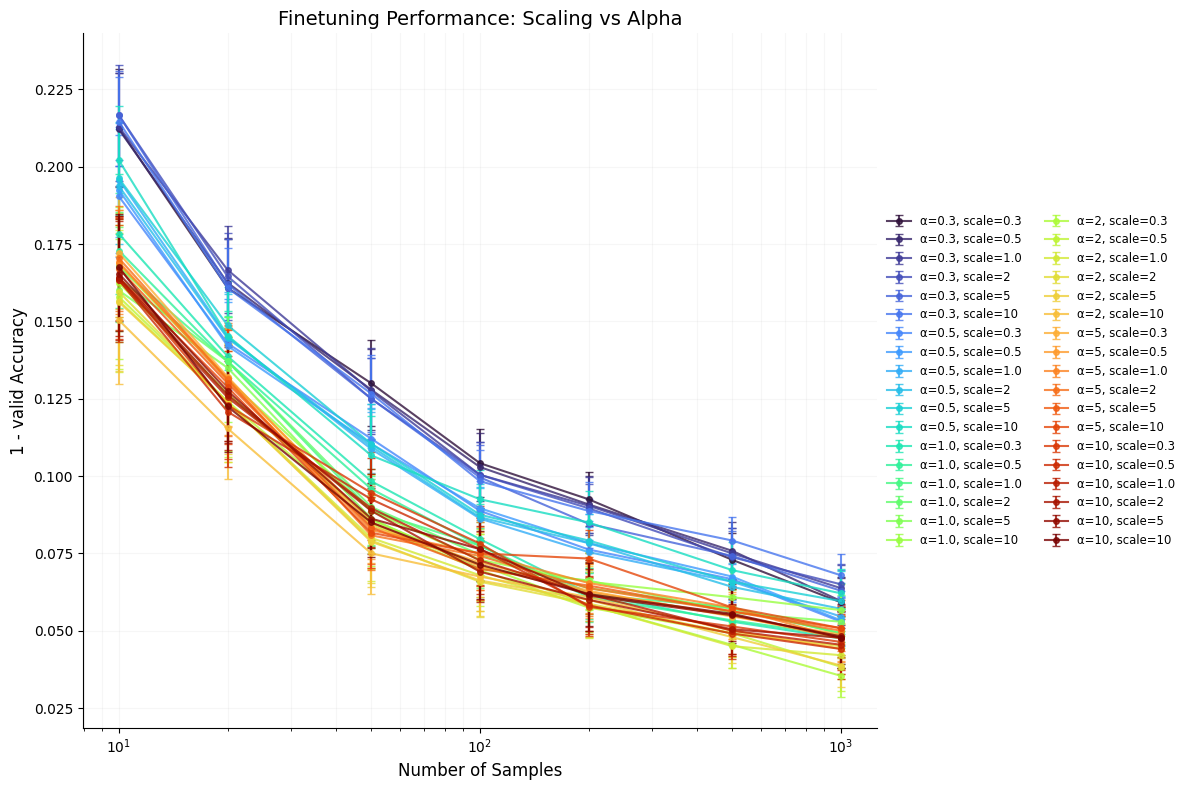

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _err_from_vals(vals, error_type="se"):
    vals = np.asarray(vals, dtype=float)
    if len(vals) == 0:
        return np.nan, np.nan
    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    err = std if error_type == "std" else std / np.sqrt(len(vals))
    return mean, err

def plot_merged_run_and_csv(
    run_data,
    metric_name,          
    type_val,             
    alphas,
    scaling_values,       
    samples,
    seeds,
    csv_path=None,        
    csv_metric="valid",   
    csv_mode=None,        
    group_col="scaling",  
    log_x=True,
    use_one_minus_acc=True,
    error_type="se",      
):
    assert error_type in {"std", "se"}
    fig, ax = plt.subplots(figsize=(12, 8))

    # Using a larger colormap for many combinations
    run_cmap = plt.get_cmap("turbo") 
    total_combos = len(alphas) * len(scaling_values)

    # --------- RUN_DATA PLOT ----------
    metric_lower = str(metric_name).lower()
    do_one_minus_run = use_one_minus_acc and ("acc" in metric_lower or "accuracy" in metric_lower)

    line_count = 0
    for alpha in alphas:
        for sc_last in scaling_values:
            means, errs = [], []
            
            for sample in samples:
                vals = []
                try:
                    # Accessing: run_data[metric][alpha][sample][scaling]
                    # This returns the list of seed arrays we loaded earlier
                    seed_results = run_data[metric_name][alpha][sample][sc_last]
                    
                    for data_matrix in seed_results:
                        data_dict = data_matrix.item() if hasattr(data_matrix, "item") else data_matrix
                        # Get the max value for 'valid' or 'train'
                        y = np.max(data_dict[type_val])
                        if do_one_minus_run:
                            y = 1.0 - y
                        vals.append(y)
                except (KeyError, IndexError, TypeError, ValueError):
                    continue

                m, e = _err_from_vals(vals, error_type=error_type)
                means.append(m)
                errs.append(e)

            # Skip if no data was found for any sample size in this alpha/scaling combo
            if np.all(np.isnan(means)):
                continue

            color = run_cmap(line_count / max(1, total_combos - 1))
            ax.errorbar(
                samples, means, yerr=errs,
                label=f"α={alpha}, scale={sc_last}",
                color=color,
                linestyle="-",
                marker="o",
                markersize=4,
                linewidth=1.5,
                capsize=3,
                alpha=0.8
            )
            line_count += 1

    # --------- CSV PLOT (Optional) ----------
    if csv_path is not None:
        # (Standard CSV logic remains as before)
        pass

    # --------- Styling ----------
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    if log_x:
        ax.set_xscale("log")

    ylabel = f"1 - {type_val} Accuracy" if do_one_minus_run else f"{type_val} {metric_name}"
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Number of Samples", fontsize=12)
    
    # Move legend outside because there are many lines
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small', frameon=False, ncol=2)
    
    plt.title(f"Finetuning Performance: Scaling vs Alpha", fontsize=14)
    plt.grid(True, which="both", ls="-", alpha=0.1)
    plt.tight_layout()
    plt.show()

# --- Execute ---
plot_merged_run_and_csv(
    run_data=run_data,
    metric_name="accs",
    type_val="valid",
    alphas=[0.3, 0.5, 1.0, 2, 5, 10],
    scaling_values=[0.3, 0.5, 1.0, 2, 5, 10],
    samples=[10, 20, 50, 100, 200, 500, 1000],
    seeds=list(range(50)),
    log_x=True,
    use_one_minus_acc=True,
    error_type="se"
)

In [ ]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path

# --- Configuration ---
seeds = list(range(10))
alphas = [0.1, 0.5, 1.0]
n_samples = [10, 50, 100, 200, 500, 1000]
base_path = Path("/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/ensd")

# Nested dictionary for structured access
run_data = {
    "df": {a: {s: [] for s in n_samples} for a in alphas},
}

all_long = []  # Stores long-format rows for every run
all_wide = []  # Stores wide-format per run
# --- Data Loading Loop ---
for alpha in alphas:
    for seed in seeds:
        for n_sample in n_samples:
            # Construct folder name based on experimental parameters
            folder_name = (
                f"random_seed={seed}--n_samples={n_sample}--alpha_load={alpha}"
            )
            dir_path = base_path / folder_name
            csv_path = dir_path / "df.csv"

            if not csv_path.exists():
                print(f'downloaded {csv_path}')
                continue

            # --- Read CSV (long format: value, variable, layer) ---
            df = pd.read_csv(csv_path)

            # Cleanup: drop stray index column if present
            if "Unnamed: 0" in df.columns:
                df = df.drop(columns=["Unnamed: 0"])

            # Ensure expected columns exist
            expected = {"value", "variable", "layer"}
            missing = expected - set(df.columns)
            if missing:
                raise ValueError(f"{csv_path} is missing columns: {missing}")

            # Enforce data types
            df["value"] = df["value"].astype(float)
            df["layer"] = df["layer"].astype(int)

            # Add metadata for filtering/grouping
            df["alpha"] = float(alpha)
            df["seed"] = int(seed)
            df["n_samples"] = int(n_sample)

            # Save in nested structure and global list
            run_data["df"][alpha][n_sample].append(df)
            all_long.append(df)

            # --- Optional: build wide-format for this run ---
            # Transforms: Layer | Variable_A_Value | Variable_B_Value
            df_wide = (
                df.pivot(index="layer", columns="variable", values="value")
                  .reset_index()
            )
            df_wide["alpha"] = float(alpha)
            df_wide["seed"] = int(seed)
            df_wide["n_samples"] = int(n_sample)
            all_wide.append(df_wide)

# --- Final Aggregation ---
if all_long:
    df_all_long = pd.concat(all_long, ignore_index=True)
else:
    df_all_long = pd.DataFrame()

if all_wide:
    df_all_wide = pd.concat(all_wide, ignore_index=True)
else:
    df_all_wide = pd.DataFrame()

print("All long-format rows:", df_all_long.shape)
print("All wide-format rows:", df_all_wide.shape)


downloaded /nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/ensd/random_seed=0--n_samples=10--alpha_load=0.1/df.csv
downloaded /nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/ensd/random_seed=0--n_samples=50--alpha_load=0.1/df.csv
downloaded /nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/ensd/random_seed=0--n_samples=100--alpha_load=0.1/df.csv
downloaded /nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/ensd/random_seed=0--n_samples=200--alpha_load=0.1/df.csv
downloaded /nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/ensd/random_seed=0--n_samples=500--alpha_load=0.1/df.csv
downloaded /nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/ensd/random_seed=0--n_samples=1000--alpha_load=0.1/df.csv
downloaded /nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/ensd/random_seed=1--n_samples=10--alpha_load=0.1/df.csv
downloaded /nfs/nhome/live/cdomine/nested_feature/